In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

from figure_params import disease_colors


import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from spatialdata_io import visium_hd
import spatialdata_plot
import spatialdata as sd
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent

from spatialdata.transformations import (
    Affine,
    MapAxis,
    Scale,
    Sequence,
    Translation,
    get_transformation,
    set_transformation,
)
import math

/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Figure 6A

In [3]:
def threshold(x,t):
    idx = x<t
    x[idx] = 0
    return(x)

def score_v2(adata,genes,score_name,log=True):
    guse = genes[genes.isin(adata.var.index)]
    adata.obs[score_name] = adata[:,guse].X.sum(axis=1)
    
    if log:
        adata.obs[score_name] = np.log2(1+adata.obs[score_name])

#M = pd.read_csv('../data/cell_type_coarse_top20_markergenes_specific_method.csv')
F = pd.read_csv('../data/cell_type_fine_top20_markergenes_specific_method.csv')

# Load spaital data
samples = ['FL14','FL33','FL58','tFL137']

fl = dict()
for s in samples:
    fl[s] = sd.read_zarr(f'/mnt/fl-data/HD_zarr/{s}.zarr')


for ct,g in F[F['cell_type_fine'].isin(['FRC','CCL21+ FRC','APOE+ M0'])].groupby('cell_type_fine'):
    for sample in samples:
        score_name = f'{ct.replace("+","").replace(" ","")}_fine_score'
        score_v2(fl[sample]['square_016um'],g['names'],score_name)
        
        
thetas = {'FL14':math.pi,
             'FL33':7*math.pi/6,
             'FL58':0,
             'tFL137':math.pi/4}
for s in samples:
    
    theta = thetas[s]

    rotation = Affine(
    [
        [math.cos(theta), -math.sin(theta), 0],
        [math.sin(theta), math.cos(theta), 0],
        [0, 0, 1],
    ],
    input_axes=("x", "y"),
    output_axes=("x", "y"),
    )
    
    for im in [fl[s].images[f"{s}_lowres_image"],
               fl[s].images[f"{s}_full_image"],
               fl[s][f"{s}_square_008um"],
               fl[s][f"{s}_square_016um"]]:
        cur_trans = get_transformation(im)
        seq = Sequence([cur_trans,rotation])

        set_transformation(im, seq, to_coordinate_system="global_rotated")
        
# x, y, radius
small_centers = {'FL14' : (-35000, -40000,8000),
               'FL33' : (-22000, -50000,8000),
               'FL58' : (35000, 50000,8000),
               'tFL137' : (-6000, 40000,8000)}

small_coords = {s : ([v[0]-v[2],v[1]-v[2]],
                     [v[0]+v[2],v[1]+v[2]]) for s,v in small_centers.items()}


fl_small = {s : f.query.bounding_box(
    min_coordinate=small_coords[s][0],
    max_coordinate=small_coords[s][1],
    axes=("x", "y"),
    target_coordinate_system="global_rotated") for s,f in fl.items()}



/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  co

## H&E plots

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30569947..1.0103627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23857868..1.0101523].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12785389..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12844037..1.0].


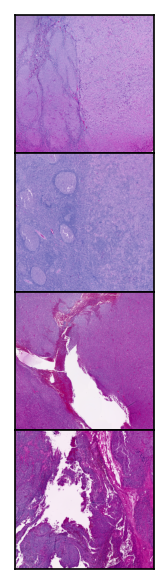

In [4]:
f,ax = plt.subplots(4)

i=0
for s in samples:
    fl_small[s].pl.render_images(f"{s}_full_image").pl.show(coordinate_systems="global_rotated",ax=ax[i])
    ax[i].set_title('')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
    ax[i].set_xlim([small_coords[s][0][0],small_coords[s][1][0]])
    ax[i].set_ylim([small_coords[s][1][1],small_coords[s][0][1]])
    i+=1
plt.subplots_adjust(wspace=0, hspace=0)

## Gene signature plots

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30569947..1.0103627].
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `FL14_square_016um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `square_016um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30569947..1.0103627].
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `FL14_square_016um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/h

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12844037..1.0].
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `tFL137_square_016um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `square_016um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12844037..1.0].
/home/njharlen/anaconda3/envs/spatial/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `tFL137_square_016um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/njha

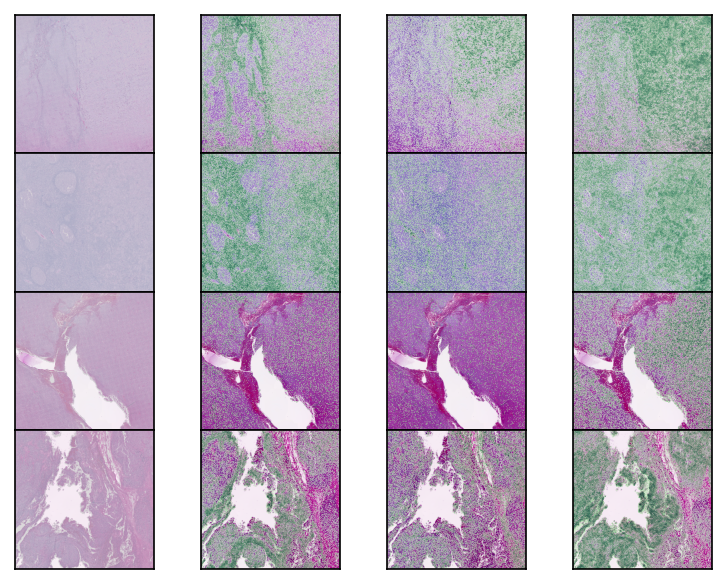

In [6]:
cell_types = ['FDC','CCL21FRC_fine','FRC_fine','APOEM0_fine']

f,ax = plt.subplots(4,len(cell_types))

new_cmap = set_zero_in_cmap_to_transparent(cmap="Greens")

i=0
for s in samples:
    j=0
    
    for ct in cell_types:
    
        fl_small[s].pl.render_images(f'{s}_full_image').pl.render_shapes(
        f'{s}_square_016um', color=f'{ct}_score',cmap=new_cmap,method='matplotlib'
                ).pl.show(coordinate_systems="global_rotated",
              title=f"bin_size=16µm",
              figsize=(10, 10),
              ax=ax[i,j],
              colorbar=False)
        
        ax[i,j].set_xlim([small_coords[s][0][0],small_coords[s][1][0]])
        ax[i,j].set_ylim([small_coords[s][1][1],small_coords[s][0][1]])
    
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        
        if i==0:
            ax[i,j].set_title('')
        else:
            ax[i,j].set_title('')
        
        j+=1
    
    
    i+=1
plt.subplots_adjust(wspace=0, hspace=0)

## Volcano plots

In [1]:
def volcano(df,thresh=.25,ax=None,label=False,min_size=1,max_size=50,palette=None,
            label_top_n=None,
           label_genes = None,use_text_adjustment=True,label_sig_only=True):
    gene_show = df[df['adj.P.Val']<thresh].sort_values('logFC').index
    
    df['sig']='nonsignificant'
    df.loc[(df['adj.P.Val']<thresh)&(df['logFC']>0),'sig']='up'
    df.loc[(df['adj.P.Val']<thresh)&(df['logFC']<0),'sig']='down'
    
    if palette is None:
        palette = {'nonsignificant':'gray','up':'blue','down':'red'}
    
    
    df['nlogp'] = -1*np.log10(df['P.Value'])
    df['size'] = df['nlogp']*df['logFC'].abs()
    df['size'] = df['size']/df['size'].max()
    
    if ax is None:
        f,ax = plt.subplots(1)
    g=sns.scatterplot(x="logFC",y="nlogp",data=df,hue='sig',size="size",sizes=(min_size,max_size),
                      ax=ax,palette=palette,legend=False,rasterized=True)
    
    
    ax.grid(False)
    
    # Balance xlim
    xl = ax.get_xlim()
    xl_max = max(abs(xl[0]),abs(xl[1]))
    ax.set_xlim([-1*xl_max,xl_max])
    
    
    if label:
        if label_top_n is not None:
            df_s = df.sort_values('P.Value')
            label_idx = list(df_s[df_s['logFC']>0].index[0:label_top_n]) + \
                list(df_s[df_s['logFC']<0].index[0:label_top_n])
        elif label_genes is not None:
            label_idx = df.index.isin(label_genes)
            if label_sig_only:
                label_idx=label_idx&(df['adj.P.Val']<thresh)
        else:
            label_idx = df['adj.P.Val']<thresh
            
        texts = [ax.text(row['logFC'],row['nlogp'],gene) for 
                 gene,row in df.loc[label_idx].iterrows()]
        if use_text_adjustment:
            adjust_text(texts,ax=ax)
        


In [4]:
samples = ['FL14','FL33','FL58','tFL137']
path = '../data'

dfs = dict()
for sample in samples:
    # DE files from loupe browser
    df = pd.read_csv(f'{path}/{sample}_histology_DE.csv')
    
    df = df.set_index('FeatureName')
    df['logFC'] = df['diffuse Log2 Fold Change']

    df['P.Value']=df['diffuse P-Value']
    df['adj.P.Val']=df['diffuse P-Value']

    dfs[sample] = df
dfm = pd.concat([df.assign(patient=s) for s,df in dfs.items()],axis=0)
dfm['pos'] = dfm['logFC'] > 0

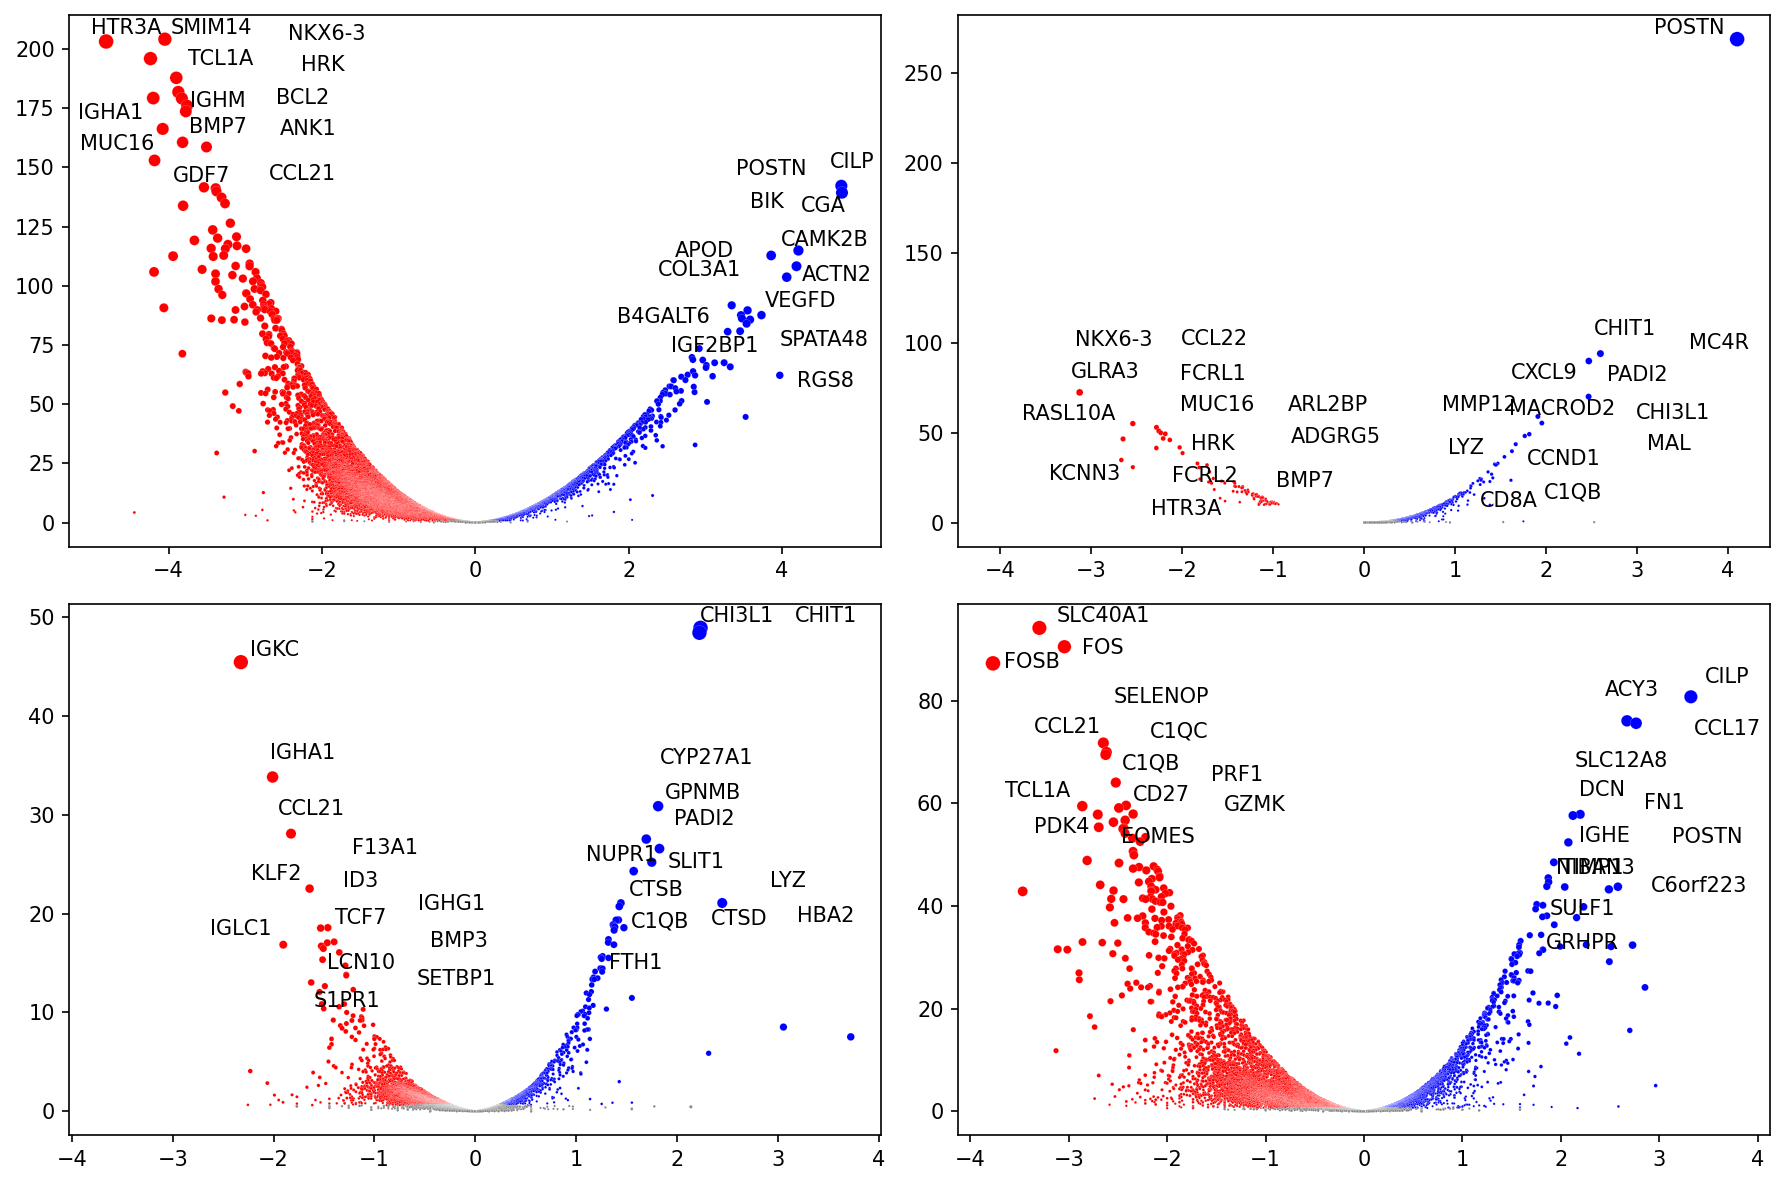

In [5]:
f,ax = plt.subplots(2,2,figsize=(12,8))
ax = ax.reshape(-1)

i=0
for sample,df in dfs.items():
    volcano(df,ax=ax[i],label_top_n=13,label=True)
    
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    i+=1
plt.tight_layout()